In [3]:
!python3 -m pip install scipy

__numpy (np)__ – Provides fast numerical operations and array handling, useful for calculations like mean, median, and standard deviation.

__pandas (pd)__ – Handles data in tables (DataFrames), making it easy to clean, manipulate, and analyze CSV datasets.

__seaborn (sns)__ – A high-level visualization library built on Matplotlib; great for attractive statistical plots like boxplots, bar charts, and distributions.

__matplotlib.pyplot (plt)__ – The core plotting library; used for customizing and displaying charts.

__scipy.stats__ – Provides statistical functions like t-tests, correlations, and other analysis tools.

__%matplotlib inline-- – Ensures plots display directly inside the notebook.

__sns.set(style="whitegrid")__ – Applies a clean grid style to Seaborn plots for better readability.

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

%matplotlib inline
sns.set(style="whitegrid")

#### __`Data Wrangling`__

In [5]:
# Reads the CSV file and loads it into a Pandas DataFrame called df.

df = pd.read_csv("1739523823_ausapparalsales4thqrt2020.zip")

# Displays the first 5 rows so you can see the data and check that it loaded correctly.
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


#### __`Inspecting the Data`__

In [7]:
# Shows data types for each column and helps identify missing data
df.info()

# Provides descriptive statistics for numeric columns to detect outliers or strange values
df.describe()

# Lists all column names to verify expected columns are presen
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')

#### __`Missing Value Detection`__

__`isna()`__ Checks every cell in the DataFrame to see if it is missing (NaN)

__`sum()`__ Counts how many missing values exist in each column.__

In [10]:

df.isna().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

__`df.isna()`__ Creates a True/False table showing where values are missing.

__`.any(axis=1)`__ Checks each row to see if it contains at least one missing value.


In [11]:
df[df.isna().any(axis=1)]

,Date,Time,State,Group,Unit,Sales


#### __`Data Cleaning`__

__`dropna()`__ removes all rows that contain any missing (NaN) values.

In [12]:
df = df.dropna()

#### __`Data Validation`__

Filters the dataset to display rows where sales are negative and units are negative

In [43]:
df[df["Sales"] < 0]
df[df["Unit"] < 0]

,Time,State,Group,Unit,Sales,Sales_Normalized,Units_Normalized,Hour
Date,,,,,,,,


In [15]:
df.columns

Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')

In [9]:
# df.columns.str.strip() removes leading and trailing spaces from column names.

df.columns = df.columns.str.strip()
df.columns

Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='object')

#### __`Handling Missing Values`__

In [10]:
# Any missing values (NaN) are replaced with the mean (average) of the Sales column.
df["Sales"] = df["Sales"].fillna(df["Sales"].mean())

# Any missing values are replaced with the median of the Unit column.
df["Unit"] = df["Unit"].fillna(df["Unit"].median())

#### __`Checking for Invalid Data Values`__

In [19]:
df[df["Sales"] < 0]
df[df["Unit"] < 0]

,Date,Time,State,Group,Unit,Sales


In [12]:
# This rescales values so that the minimum value becomes 0 and the maximum value becomes 1 and all other values fall between 0 and 1

df["Sales_Normalized"] = (df["Sales"] - df["Sales"].min()) / (df["Sales"].max() - df["Sales"].min())

df["Units_Normalized"] = (df["Unit"] - df["Unit"].min()) / (df["Unit"].max() - df["Unit"].min())

#### __`Data Analysis`__

__`df.groupby("State")`__ Splits the dataset into groups based on each unique State.

__`["Sales"]`__ Selects the Sales column.

__`.sum()`__ Adds up total Sales for each State.

__`state_sales`__ Stores the aggregated results.

In [21]:
state_sales = df.groupby("State")["Sales"].sum()
state_sales

State
NSW     74970000
NT      22580000
QLD     33417500
SA      58857500
TAS     22760000
VIC    105565000
WA      22152500
Name: Sales, dtype: int64

#### __`Descriptive Statistics`__

In [22]:
df["Sales"].mean()
df["Sales"].median()
df["Sales"].mode()
df["Sales"].std()

np.float64(32253.506943966073)

__np.float64 = NumPy 64-bit floating point number__

__32253.5069... = The actual mean (average) Sales value__

__So the average sales value is approximately 32,253.51.__

In [23]:
df["Unit"].mean()
df["Unit"].median()
df["Unit"].mode()
df["Unit"].std()

np.float64(12.90140277758643)

__np.float64 → It’s a NumPy 64-bit decimal number.__

__12.90140277758643 is the average Unit value is about 12.90.__


__On average, about 13 units are recorded per entry in your dataset.__

#### __`Grouping`__

__`groupby("State")`__ Groups all rows by each unique State

__`["Sales"]`__ Selects the Sales column

__`.sum()`__ → Adds up total sales for each state

In [24]:
state_sales = df.groupby("State")["Sales"].sum()

highest_state = state_sales.idxmax()
lowest_state = state_sales.idxmin()

highest_state, lowest_state

(' VIC', ' WA')

__' VIC' (Victoria) has the highest total sales__

__' WA'(Western Australia) has the lowest total sales__

In [15]:
# df.groupby("Group") groups all rows that have the same value in the "Group" column.

group_sales = df.groupby("Group")["Sales"].sum()
group_sales

Group
Kids       85072500
Men        85750000
Seniors    84037500
Women      85442500
Name: Sales, dtype: int64

__Total Sales by Group:__

* Men → 85,750,000 (Highest)

* Women → 85,442,500

* Kids → 85,072,500

* Seniors → 84,037,500 ❌ (Lowest)

| Function   | What It Finds          |
| ---------- | ---------------------- |
| `idxmax()` | Best performing group  |
| `idxmin()` | Worst performing group |


In [16]:
group_sales.idxmax(), group_sales.idxmin()

(' Men', ' Seniors')

#### __`Data Cleaning`__

In [18]:
# It converts the "Date" column into a proper datetime format that pandas understands.

df["Date"] = pd.to_datetime(df["Date"])

In [19]:
# makes the "Date" column the index of the DataFrame.

df.set_index("Date", inplace=True)

__`df["Sales"]`__ Selects the Sales column.

__`.resample("W")`__ Resamples the data by week.

__`.sum()`__ For each week, it adds up all sales values.

In [33]:
weekly_sales = df["Sales"].resample("W").sum()

__`df["Sales"]`__ Selects the Sales column.

__`.resample("ME")`__ Resamples the data by Month End frequency.

__`.sum()`__ For each month, it adds up all sales values.

In [30]:
monthly_sales = df["Sales"].resample("ME").sum()

__`df["Sales"]`__ Selects the Sales column.

__`.resample("QE")`__ Groups all data into 3-month periods

__`.sum()`__ Adds all sales within each quarter.


In [23]:
quarterly_sales = df["Sales"].resample("QE").sum()

In [24]:
print(quarterly_sales)

Date
2020-12-31    340302500
Freq: QE-DEC, Name: Sales, dtype: int64


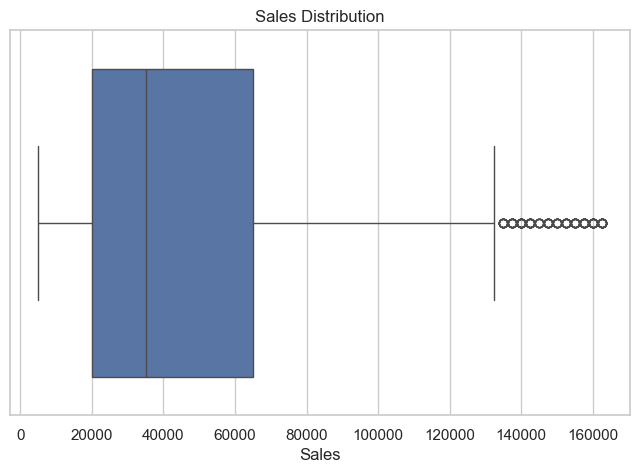

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Sales"])
plt.title("Sales Distribution")
plt.show()

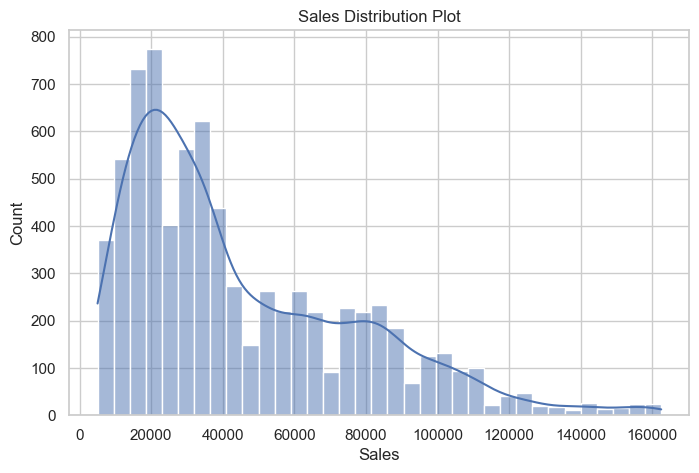

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], kde=True)
plt.title("Sales Distribution Plot")
plt.show()

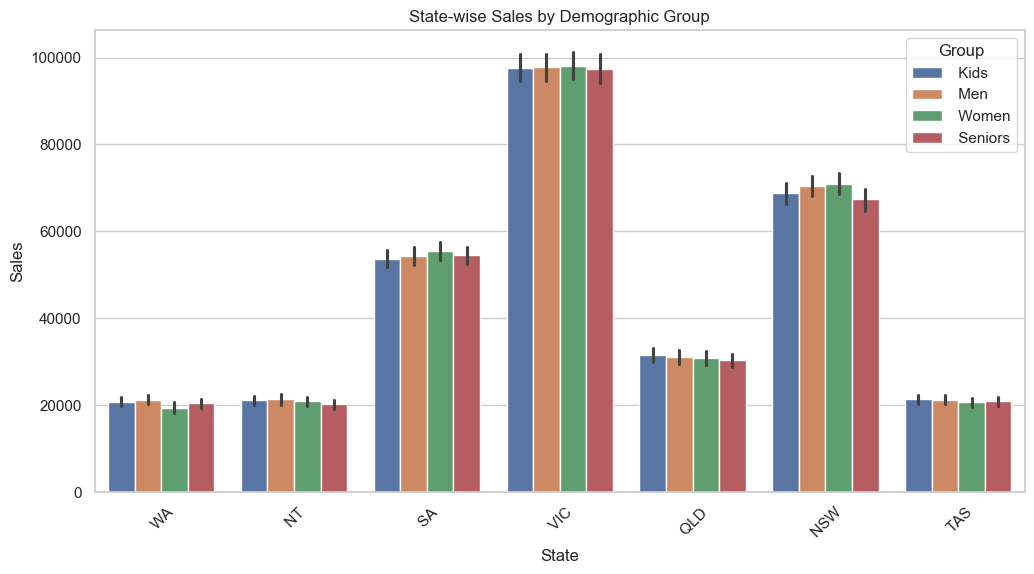

In [38]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x="State", y="Sales", hue="Group")
plt.xticks(rotation=45)
plt.title("State-wise Sales by Demographic Group")
plt.show()

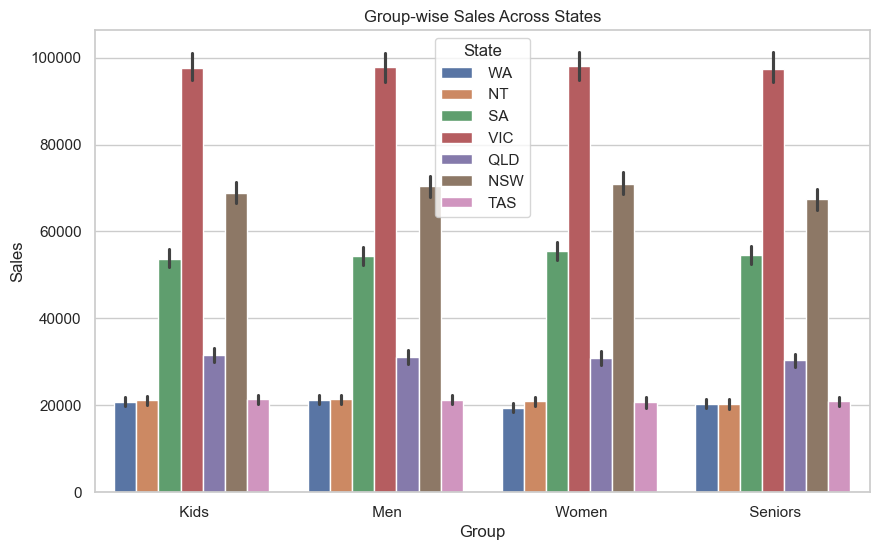

In [39]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Group", y="Sales", hue="State")
plt.title("Group-wise Sales Across States")
plt.show()

In [31]:
df.columns


Index(['Time', 'State', 'Group', 'Unit', 'Sales', 'Sales_Normalized',
       'Units_Normalized'],
      dtype='object')

### State Performance

The state generating the __highest total revenue is Victoria__, based on the idxmax() analysis.

This indicates strong market demand and effective sales performance in this region.



The state generating the __lowest total revenue is Western Australia__, based on the idxmin() result.

This suggests weaker customer engagement or potential market challenges in this region.

### Group Performance

Highest Revenue Group:

Men → 85,750,000

Lowest Revenue Group:

Seniors → 84,037,500

Important insight:

The difference between highest and lowest is:

85,750,000 − 84,037,500 = 1,712,500

That’s only about a 2% variation.

This tells us:

👉 Sales performance across groups is relatively balanced.
👉 No group is drastically underperforming.
👉 There is room for optimization rather than restructuring.

### Recommendations

__To improve performance in low-revenue states, the following strategies are recommended:__

* Offer seasonal discounts to attract price-sensitive customers.

* Introduce loyalty programs to increase repeat purchases.

* Implement hyper-personalized promotions using customer purchase data.

* Collaborate with local influencers to increase brand visibility and trust.

* Adjust inventory based on demographic trends to better match customer demand.


__To improve performance based on groups, the following strategies are recommended:__

* Expand the Men’s product line.

* Introduce premium or limited-edition collections.

* Allocate slightly higher marketing budget to maintain growth momentum.

* Launch targeted discounts or loyalty programs for seniors.

* Adjust product positioning for seniors  (comfort, quality, accessibility).

* Run age-specific marketing campaigns.

### Conclusion

Analysis shows that Victoria leads in revenue generation, while Western Australia underperforms.

Strategic focus should be placed on targeted promotions, loyalty initiatives, and localized marketing in weaker regions.

Additionally, staffing optimization during peak hours and promotional incentives during off-peak periods can significantly improve operational efficiency and sales performance.

